# Phase 5 Modeling 
##### This notebook builds and evaluates churn prediction models, and documents a two-stage data leakage investigation that shaped the final results.

**1. Data Loading & Target/Feature Definition**

Loads the merged dataset and defines `has_churned` as the target. `drop_cols` excludes 
ID columns, event-timestamp columns, and — critically — columns later identified as 
directly derived from `churn_events.csv` (a table that only contains rows for accounts 
that had already churned). Keeping those columns would let the model "cheat" by reading 
the answer off a proxy column instead of learning genuine patterns.

In [1]:
import pandas as pd
import numpy as np
data = pd.read_csv("../data/final_integrated_dataset.csv")

# Aggregate to one row per account
agg_dict = {
    'mrr_amount': 'mean',
    'arr_amount': 'mean',
    'seats_subscription': 'mean',
    'upgrade_flag': 'sum',
    'downgrade_flag': 'sum',
    'usage_count_feat': 'mean',
    'usage_duration_secs_feat': 'mean',
    'error_count_feat': 'mean',
    'total_tickets': 'mean',
    'num_escalated_tickets': 'mean',
    'satisfaction_score_ticket': 'mean',
    'resolution_time_hours_ticket': 'mean',
    'first_response_time_minutes_ticket': 'mean',
    'subscription_duration_days': 'mean',
    # account-level fields
    'country': 'first',
    'seats_account': 'first',
    'plan_tier_account': 'first',
    'referral_source': 'first',
    'is_trial_y': 'first',
    'has_churned': 'first',  # the target — same for every row of an account
}

# Only keep keys that actually exist in dataframe
agg_dict = {k: v for k, v in agg_dict.items() if k in data.columns}

account_df = data.groupby('account_id').agg(agg_dict).reset_index()
print(account_df.shape)
print(account_df['has_churned'].value_counts(normalize=True))

(500, 21)
has_churned
True     0.704
False    0.296
Name: proportion, dtype: float64


In [2]:
# Ratio/rate features
account_df['tickets_per_seat'] = account_df['total_tickets'] / account_df['seats_account'].replace(0, 1)
account_df['escalation_rate'] = account_df['num_escalated_tickets'] / account_df['total_tickets'].replace(0, 1)

error_sum = data.groupby('account_id')['error_count_feat'].sum()
usage_sum = data.groupby('account_id')['usage_count_feat'].sum()
account_df = account_df.merge(
    (error_sum / usage_sum.replace(0, 1)).rename('errors_per_usage'),
    on='account_id', how='left'
)

# Sanity check
print(account_df[['tickets_per_seat', 'escalation_rate', 'errors_per_usage']].describe())
print("Any inf values?", np.isinf(account_df[['tickets_per_seat', 'escalation_rate', 'errors_per_usage']]).sum().sum())

       tickets_per_seat  escalation_rate  errors_per_usage
count        500.000000       500.000000        500.000000
mean           0.677117         0.047241          0.056480
std            1.154889         0.114745          0.015935
min            0.000000         0.000000          0.000000
25%            0.119851         0.000000          0.045566
50%            0.250000         0.000000          0.054621
75%            0.625000         0.000000          0.065754
max            8.000000         1.000000          0.109756
Any inf values? 0


In [3]:
target = 'has_churned'
drop_cols = ['account_id']

X = account_df.drop(columns=[target] + drop_cols)
y = account_df[target]

print(y.value_counts(normalize=True))

has_churned
True     0.704
False    0.296
Name: proportion, dtype: float64


In [4]:
data.groupby('has_churned')['subscription_duration_days'].describe()

,count,mean,std,min,25%,50%,75%,max
has_churned,,,,,,,,
False,1472.0,415.033288,186.014490,0.0,307.0,380.5,518.0,1003.0
True,3528.0,414.431122,183.471969,0.0,309.0,386.0,516.0,1000.0


In [5]:
# Confirm: does every subscription under one account share the same churn label?
churn_consistency = data.groupby('account_id')['has_churned'].nunique()
print(churn_consistency.value_counts())

has_churned
1    500
Name: count, dtype: int64


**2. Train-Test Split**

Uses `GroupShuffleSplit` (grouped by `account_id`), not a plain random split. This matters 
because one account can have multiple subscription rows — a random split lets rows from 
the same account leak across train and test, letting the model memorize account identities 
rather than generalize to unseen customers. Grouping fixes this.

In [4]:
# Train-Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**3. Preprocessing**
`StandardScaler` for numeric columns, `OneHotEncoder` for categorical columns, combined via 
`ColumnTransformer` and wrapped in a `Pipeline` alongside the model — this keeps preprocessing 
and modeling as one reproducible unit and prevents preprocessing leakage (fitting the scaler 
on the full dataset instead of just the training split).

In [7]:
# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'bool', 'string']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


**Why two models: Random Forest AND Logistic Regression**

Random Forest is the primary model — it handles non-linear relationships and feature 
interactions well, which fits messy, real-world-shaped churn data. Logistic Regression is 
included specifically as a **diagnostic baseline**, not a competing "best model" candidate. 
It's a simple, linear, low-capacity model — if Logistic Regression *also* scores unrealistically 
high, that points to a leak affecting the data itself (any model would exploit it). If Logistic 
Regression scores much lower than Random Forest, that's a signal Random Forest may be 
overfitting or exploiting something only a high-capacity model can find (e.g. memorizing 
narrow subgroups). Comparing the two was what helped confirm the leakage findings in this 
notebook were real, and not an artifact of one specific algorithm.

In [8]:
# Model: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])
rf_model.fit(X_train, y_train)

# Step 7: Predict and evaluate
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))
print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))
print("\nROC-AUC Score:", roc_auc_score(y_test, y_proba))

=== Classification Report ===
              precision    recall  f1-score   support

       False       0.00      0.00      0.00        30
        True       0.70      0.99      0.82        70

    accuracy                           0.69       100
   macro avg       0.35      0.49      0.41       100
weighted avg       0.49      0.69      0.57       100


=== Confusion Matrix ===
[[ 0 30]
 [ 1 69]]

ROC-AUC Score: 0.48500000000000004


In [9]:
# Fit the model
rf_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [5]:
# Generate predictions 
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1] 

NameError: name 'rf_model' is not defined

**4. Evaluation**

`classification_report`, `confusion_matrix`, and `roc_auc_score` are used together because 
accuracy alone is misleading on an imbalanced target (~70% churned in this dataset) — a model 
that predicts "churned" for everyone would still show high accuracy while being useless. 
ROC-AUC and per-class precision/recall give a fuller picture.

In [11]:
# Evaluation
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\nROC-AUC Score:", roc_auc_score(y_test, y_proba))

=== Classification Report ===
              precision    recall  f1-score   support

       False       0.00      0.00      0.00        30
        True       0.70      0.99      0.82        70

    accuracy                           0.69       100
   macro avg       0.35      0.49      0.41       100
weighted avg       0.49      0.69      0.57       100


=== Confusion Matrix ===
[[ 0 30]
 [ 1 69]]

ROC-AUC Score: 0.48500000000000004


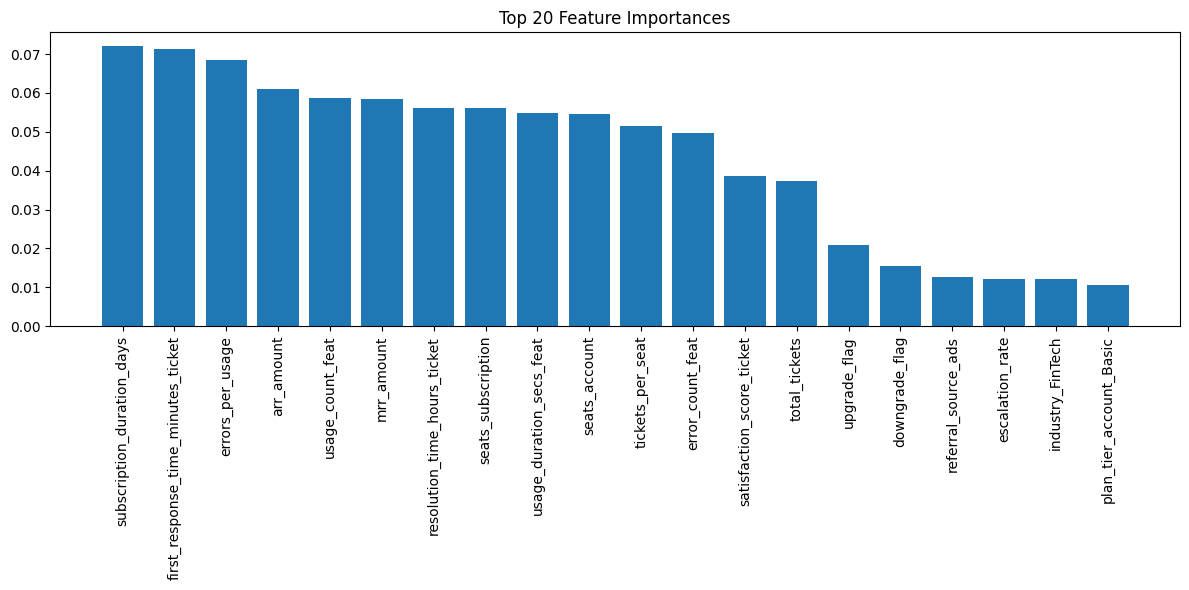

In [12]:
# Feature Importance
import matplotlib.pyplot as plt
import numpy as np

rf = rf_model.named_steps['classifier']
importances = rf.feature_importances_

# Get feature names after preprocessing
feature_names = numeric_cols + list(
    rf_model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_cols)
)

indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
plt.title("Top 20 Feature Importances")
plt.bar(range(20), importances[indices][:20], align='center')
plt.xticks(range(20), [feature_names[i] for i in indices][:20], rotation=90)
plt.tight_layout()
plt.show()

In [13]:
import numpy as np

rf = rf_model.named_steps['classifier']
importances = rf.feature_importances_

feature_names = numeric_cols + list(
    rf_model.named_steps['preprocessor']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_cols)
)

indices = np.argsort(importances)[::-1]

print("Top 15 features by importance:")
for i in indices[:15]:
    print(f"{feature_names[i]:40s} {importances[i]:.4f}")

Top 15 features by importance:
subscription_duration_days               0.0720
first_response_time_minutes_ticket       0.0714
errors_per_usage                         0.0685
arr_amount                               0.0611
usage_count_feat                         0.0588
mrr_amount                               0.0585
resolution_time_hours_ticket             0.0561
seats_subscription                       0.0560
usage_duration_secs_feat                 0.0548
seats_account                            0.0547
tickets_per_seat                         0.0515
error_count_feat                         0.0498
satisfaction_score_ticket                0.0386
total_tickets                            0.0373
upgrade_flag                             0.0208


In [14]:
# Check every column for near-perfect separation by churn status
for col in X.columns:
    if X[col].dtype in ['object', 'bool', 'string']:
        # Crosstab: does this column's value fully determine churn?
        ct = pd.crosstab(data[col], data['has_churned'], normalize='index')
        max_purity = ct.max(axis=1).mean()  # how "pure" the groups are on average
        if max_purity > 0.95:
            print(f"⚠️ '{col}' is {max_purity:.1%} pure by churn status")
    elif X[col].dtype in ['int64', 'float64']:
        corr = X[col].corr(data['has_churned'].astype(int))
        if abs(corr) > 0.7:
            print(f"⚠️ '{col}' correlation with churn: {corr:.3f}")

In [15]:
# Check for exact duplicate rows in the feature set
print("Duplicate rows in X (features only):", X.duplicated().sum())

# Check for duplicate rows where features AND target are identical
combined = pd.concat([X, y], axis=1)
print("Duplicate rows in X + y:", combined.duplicated().sum())

# How many unique accounts vs total rows? (tells us if subscriptions repeat per account)
print("Total rows:", len(data))
print("Unique account_id:", data['account_id'].nunique())

Duplicate rows in X (features only): 0
Duplicate rows in X + y: 0
Total rows: 5000
Unique account_id: 500


**7. Leakage Diagnostics (shallow tree, duplicate-row check, correlation checks, cross-validation)**

These cells don't build a "final" model — they're investigative tools used to confirm *why* 
early results looked suspiciously perfect, and to verify the final results are genuinely 
leak-free rather than assumed to be.

In [16]:
from sklearn.tree import DecisionTreeClassifier, export_text

# Shallow tree — if 2-3 splits alone get near-perfect accuracy,
# that confirms a hidden deterministic rule
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(
    rf_model.named_steps['preprocessor'].transform(X_train), 
    y_train
)

tree_pred = tree.predict(rf_model.named_steps['preprocessor'].transform(X_test))
from sklearn.metrics import accuracy_score
print("Shallow tree accuracy:", accuracy_score(y_test, tree_pred))

print("\nDecision rules:")
print(export_text(tree, feature_names=feature_names, max_depth=3))

Shallow tree accuracy: 0.68

Decision rules:
|--- total_tickets <= 1.30
|   |--- seats_account <= 3.35
|   |   |--- arr_amount <= 0.90
|   |   |   |--- class: True
|   |   |--- arr_amount >  0.90
|   |   |   |--- class: True
|   |--- seats_account >  3.35
|   |   |--- seats_account <= 5.81
|   |   |   |--- class: False
|   |   |--- seats_account >  5.81
|   |   |   |--- class: True
|--- total_tickets >  1.30
|   |--- usage_count_feat <= 0.68
|   |   |--- upgrade_flag <= 0.45
|   |   |   |--- class: False
|   |   |--- upgrade_flag >  0.45
|   |   |   |--- class: True
|   |--- usage_count_feat >  0.68
|   |   |--- is_trial_y_False <= 0.50
|   |   |   |--- class: False
|   |   |--- is_trial_y_False >  0.50
|   |   |   |--- class: True



In [17]:
data.groupby('has_churned')['satisfaction_score_ticket'].describe()


,count,mean,std,min,25%,50%,75%,max
has_churned,,,,,,,,
False,1472.0,3.731198,1.141845,0.0,3.5,4.0,4.333333,5.0
True,3528.0,3.732439,1.079116,0.0,3.5,4.0,4.333333,5.0


In [18]:
data['satisfaction_score_ticket'].isna().sum()  # is it still NaN, or was it filled?

np.int64(0)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# Test 1: Does even a simple LINEAR model get near-perfect too?
log_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])
log_model.fit(X_train, y_train)
log_proba = log_model.predict_proba(X_test)[:, 1]
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, log_proba))

# Test 2: Is the perfect score consistent across different train/test splits?
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='roc_auc')
print("5-fold CV ROC-AUC scores:", cv_scores)
print("Mean:", cv_scores.mean())

Logistic Regression ROC-AUC: 0.4366666666666667
5-fold CV ROC-AUC scores: [0.45531812 0.4431763  0.43214286 0.43880952 0.4602381 ]
Mean: 0.44593697819098493


**5. Gradient Boosting**

Added as a third, independent model family for the same reason — to confirm that a weak/strong 
result holds across fundamentally different algorithms, rather than being specific to one 
model's quirks.

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(random_state=42))
])
gb_model.fit(X_train, y_train)
gb_proba = gb_model.predict_proba(X_test)[:, 1]
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, gb_proba))

Gradient Boosting ROC-AUC: 0.36523809523809525


In [24]:
# Merge churn label onto raw feature_usage rows (via subscription_id -> account_id)
# First, get subscription_id -> account_id mapping
sub_to_account = data[['subscription_id', 'account_id', 'has_churned']].drop_duplicates()

# You'll need the raw feature_usage.csv for this — reload it fresh, not the merged/aggregated version
feature_usage = pd.read_csv("../data/ravenstack_feature_usage.csv")
feature_usage = feature_usage.merge(sub_to_account, on='subscription_id', how='left')

print(feature_usage.shape)
print(feature_usage['has_churned'].isna().sum())  # should be 0 if merge worked

# Correlation of raw usage metrics with churn, at the individual usage-record level
for col in ['usage_count', 'usage_duration_secs', 'error_count']:
    corr = feature_usage[col].corr(feature_usage['has_churned'].astype(int))
    print(f"{col}: {corr:.4f}")

(25000, 10)
0
usage_count: -0.0017
usage_duration_secs: 0.0024
error_count: 0.0010


In [25]:
support_tickets = pd.read_csv("../data/ravenstack_support_tickets.csv")  # adjust path if needed

# support_tickets links via account_id directly, not subscription_id
account_churn = data[['account_id', 'has_churned']].drop_duplicates()
support_tickets = support_tickets.merge(account_churn, on='account_id', how='left')

for col in ['resolution_time_hours', 'first_response_time_minutes', 'satisfaction_score']:
    corr = support_tickets[col].corr(support_tickets['has_churned'].astype(int))
    print(f"{col}: {corr:.4f}")

resolution_time_hours: -0.0083
first_response_time_minutes: 0.0040
satisfaction_score: -0.0017


In [26]:
feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])

feature_usage['days_from_last'] = feature_usage.groupby('subscription_id')['usage_date'].transform(
    lambda x: (x.max() - x).dt.days
)
recent = feature_usage[feature_usage['days_from_last'] <= 30].groupby('subscription_id')['usage_count'].mean()
earlier = feature_usage[feature_usage['days_from_last'] > 30].groupby('subscription_id')['usage_count'].mean()

recency_df = pd.DataFrame({'recent_usage': recent, 'earlier_usage': earlier}).dropna()
recency_df['usage_trend'] = recency_df['recent_usage'] - recency_df['earlier_usage']

recency_df = recency_df.merge(sub_to_account.set_index('subscription_id')[['has_churned']], 
                                left_index=True, right_index=True)

print(recency_df.groupby('has_churned')['usage_trend'].describe())

C:\Users\Ahana Basak\AppData\Local\Temp\ipykernel_29924\3887088879.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  feature_usage['usage_date'] = pd.to_datetime(feature_usage['usage_date'])


              count      mean       std   min       25%  50%     75%   max
has_churned                                                               
False        1402.0  0.122105  3.618689 -14.0 -2.333333  0.0  2.5000  13.6
True         3380.0 -0.011090  3.536197 -17.0 -2.343750  0.0  2.2125  14.8


In [27]:
# Rename for clarity — this is your account-level model
rf_model_account = rf_model

In [28]:
from sklearn.model_selection import GroupShuffleSplit

# Rebuild row-level X, y from the ORIGINAL row-level `data` (not account_df)
target = 'has_churned'
drop_cols_row = [
    'subscription_id', 'account_id', 'account_name',
    'start_date', 'end_date', 'signup_date', 'last_churn_date',
    'churn_flag_x', 'churn_flag_y', 'is_active',
    'total_churn_events', 'any_reactivation',
    'total_refunds', 'any_preceding_upgrade', 'any_preceding_downgrade',
    'top_reason',
]
X_row = data.drop(columns=[target] + drop_cols_row)
y_row = data[target]

gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X_row, y_row, groups=data['account_id']))
X_train_row, X_test_row = X_row.iloc[train_idx], X_row.iloc[test_idx]
y_train_row, y_test_row = y_row.iloc[train_idx], y_row.iloc[test_idx]

numeric_cols_row = X_row.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols_row = X_row.select_dtypes(include=['object', 'bool', 'string']).columns.tolist()

preprocessor_row = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols_row),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols_row)
])

rf_model_row = Pipeline(steps=[
    ('preprocessor', preprocessor_row),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'))
])
rf_model_row.fit(X_train_row, y_train_row)

row_proba = rf_model_row.predict_proba(X_test_row)[:, 1]
print("Row-level model ROC-AUC:", roc_auc_score(y_test_row, row_proba))

Row-level model ROC-AUC: 0.5224235820381947


In [29]:
import os
import joblib

# Create folders if they don't exist
os.makedirs('../models', exist_ok=True)

# Save both trained models
joblib.dump(rf_model_account, '../models/rf_model_account.pkl')
joblib.dump(rf_model_row, '../models/rf_model_row.pkl')

# Save the test sets each model was evaluated on, so Phase 6 can load them directly
X_test.to_csv('../data/X_test_account.csv', index=False)
y_test.to_csv('../data/y_test_account.csv', index=False)

X_test_row.to_csv('../data/X_test_row.csv', index=False)
y_test_row.to_csv('../data/y_test_row.csv', index=False)

print("Models and test sets saved successfully.")

Models and test sets saved successfully.
